
--- FIRST 5 ROWS ---
   order_id  customer_name     category  quantity  sales  discount region
0         1       John Doe  Electronics         2    500      0.10  North
1         2     Jane Smith    Furniture         1    300      0.05  South
2         3    Bob Johnson     Clothing         5    200      0.20   East
3         4    Alice Brown  Electronics         3    750       NaN   West
4         5  Charlie White    Furniture         2    450      0.15  North

--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       15 non-null     int64  
 1   customer_name  15 non-null     object 
 2   category       15 non-null     object 
 3   quantity       15 non-null     int64  
 4   sales          15 non-null     int64  
 5   discount       12 non-null     float64
 6   region         15 non-null     object 
dtypes: float64(1

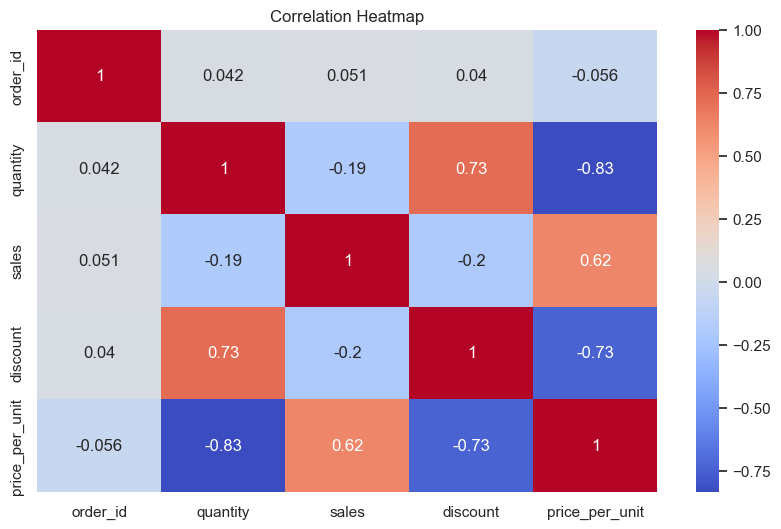

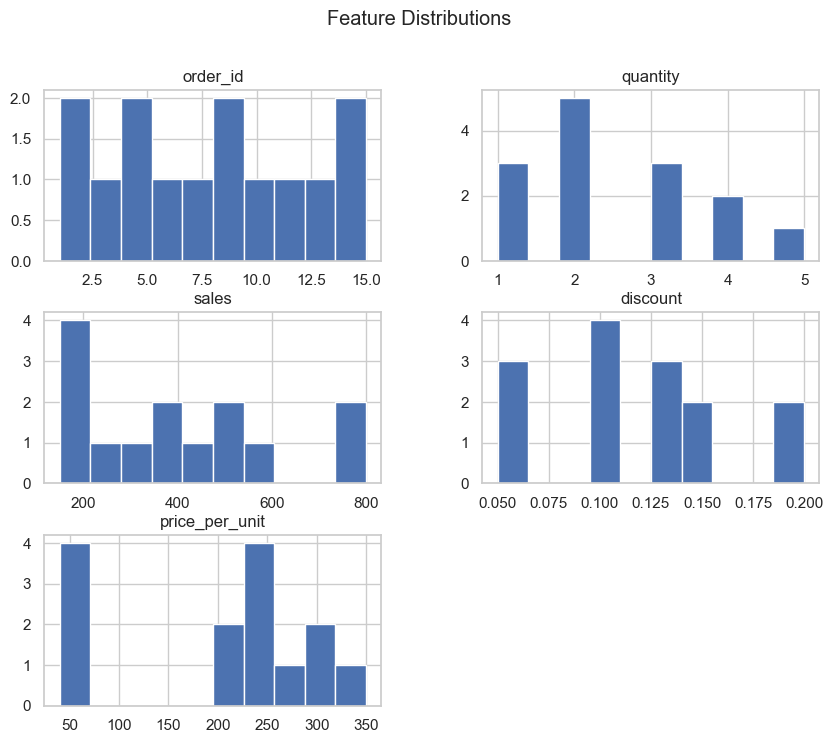

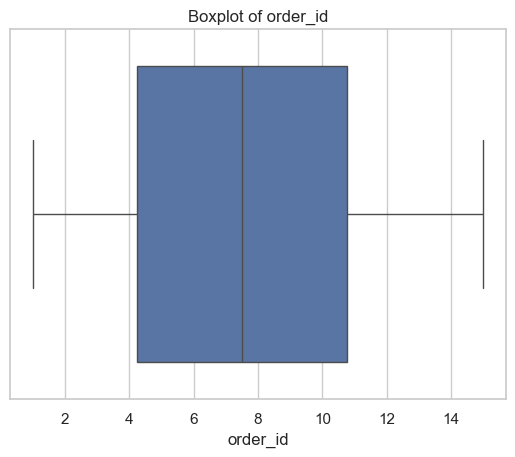

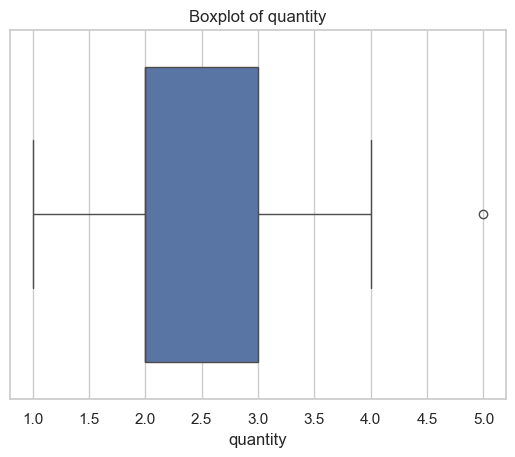

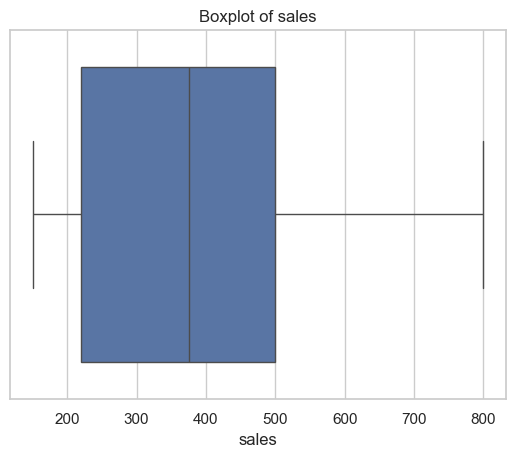

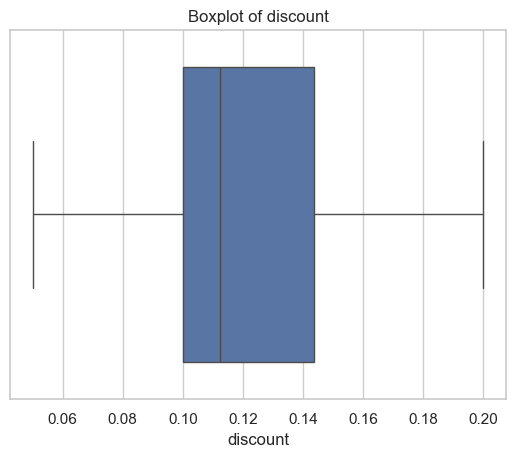

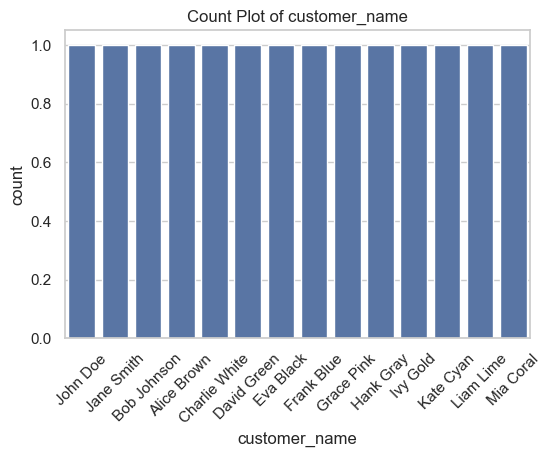

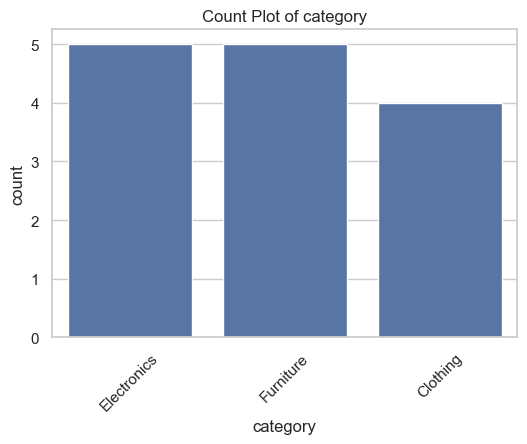

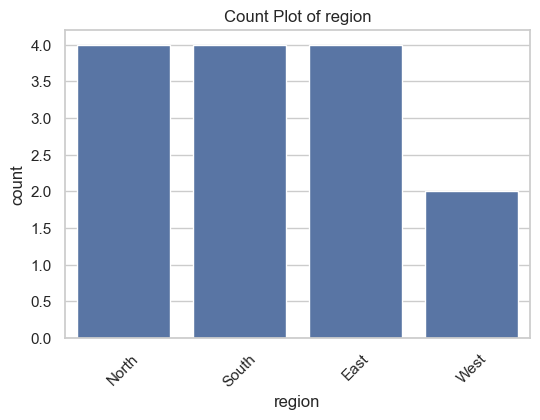

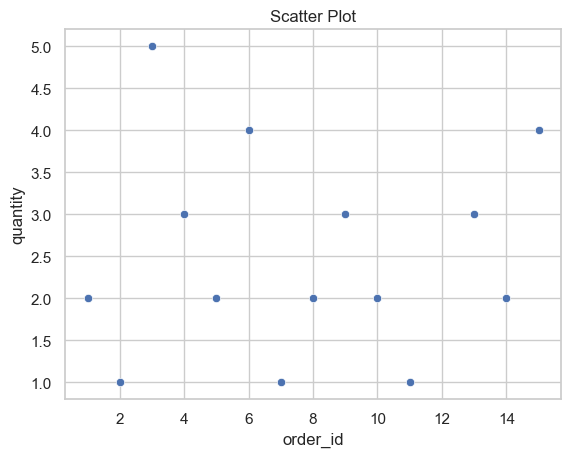


--- SUMMARY STATISTICS ---
        order_id   quantity       sales   discount  price_per_unit
count  14.000000  14.000000   14.000000  14.000000       14.000000
mean    7.714286   2.500000  402.857143   0.116071      202.083333
std     4.496641   1.224745  208.821918   0.048642      107.913758
min     1.000000   1.000000  150.000000   0.050000       40.000000
25%     4.250000   2.000000  220.000000   0.100000       89.375000
50%     7.500000   2.000000  375.000000   0.112500      250.000000
75%    10.750000   3.000000  500.000000   0.143750      262.500000
max    15.000000   5.000000  800.000000   0.200000      350.000000

--- TOP CORRELATIONS ---
order_id        order_id          1.000000
discount        quantity          0.726306
price_per_unit  sales             0.621120
sales           order_id          0.050908
order_id        quantity          0.041903
                discount          0.040193
price_per_unit  order_id         -0.056408
quantity        sales            -0.192493

In [1]:
#Customer Analysis-Data Cleaning and Visual

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

file_path = "data.csv"  
df = pd.read_csv(file_path)

print("\n--- FIRST 5 ROWS ---")
print(df.head())

print("\n--- DATA INFO ---")
print(df.info())

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])
df.drop_duplicates(inplace=True)

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

if 'sales' in df.columns and 'quantity' in df.columns:
    df['price_per_unit'] = df['sales'] / df['quantity']

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

df.hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

for col in df.select_dtypes(include='object').columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(f"Count Plot of {col}")
    plt.show()

if len(numeric_cols) >= 2:
    plt.figure()
    sns.scatterplot(x=df[numeric_cols[0]], y=df[numeric_cols[1]])
    plt.title("Scatter Plot")
    plt.show()

df.to_csv("cleaned_data.csv", index=False)

print("\n--- SUMMARY STATISTICS ---")
print(df.describe())

print("\n--- TOP CORRELATIONS ---")
corr = df.corr(numeric_only=True)
print(corr.unstack().sort_values(ascending=False).drop_duplicates())

print("\nProject Completed Successfully!")